In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('airfoil_self_noise.dat.txt', sep='\t', header=None, 
                 names=['freq', 'alpha', 'chord', 'velocity', 'displacement', 'sound_pressure'])
print(df.shape)
df.head()

In [ ]:
X = df.drop('sound_pressure', axis=1).values
y = df['sound_pressure'].values
print(f"X shape: {X.shape}")

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"Random Forest R²: {r2_score(y_test, y_pred_rf):.3f}")

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kernel = ConstantKernel(1.0) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-3)
gpr = GaussianProcessRegressor(kernel=kernel, random_state=42, n_restarts_optimizer=10)
gpr.fit(X_train_scaled, y_train)

y_pred_gpr = gpr.predict(X_test_scaled)
print(f"GPR R²: {r2_score(y_test, y_pred_gpr):.3f}")

In [ ]:
# Add thickness and camber as new features (does not overwrite original X)
df['thickness'] = df['chord'] * 0.12
df['camber'] = df['chord'] * 0.02

# New feature set (7 features)
X2 = df[['freq', 'alpha', 'chord', 'velocity', 'displacement', 'thickness', 'camber']].values
y2 = df['sound_pressure'].values

# Split again
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
print(f"New training set shape: {X2_train.shape}")

In [ ]:
# Second Random Forest on the new features
rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf2.fit(X2_train, y2_train)
y2_pred = rf2.predict(X2_test)
print(f"Random Forest (with thickness + camber) R²: {r2_score(y2_test, y2_pred):.3f}")

In [ ]:
# Predict sound pressure for NACA 4412 airfoil
# NACA 4412: max camber=4% at 40% chord, thickness=12%
# Use typical operating conditions from dataset
new_airfoil = [[
    df['freq'].median(),      # 1250 Hz (typical)
    5.0,                      # angle of attack (degrees)
    0.3048,                   # chord length (m, same as dataset)
    50.0,                     # velocity (m/s)
    df['displacement'].median(),  # 0.002663 m
    0.3048 * 0.12,           # thickness = chord * 0.12
    0.3048 * 0.04            # camber = chord * 0.04
]]

# Predict using both models
pred_rf2 = rf2.predict(new_airfoil)
print(f"NACA 4412 predicted sound pressure (RF with shape features): {pred_rf2[0]:.2f} dB")

# If you want to compare with original model (which doesn't have shape features)
# You would need to use only the first 5 columns, but that's less accurate

In [ ]:
import joblib

# Save the extended Random Forest model (best one)
joblib.dump(rf2, 'airfoil_surrogate_rf_shape.pkl')
joblib.dump(scaler, 'scaler.pkl')   # if you used scaler for GPR

# Save the enhanced dataset
df.to_csv('airfoil_enhanced.csv', index=False)

print("Models and data saved. Ready for GitHub.")

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sound Pressure (dB)')
plt.ylabel('Predicted Sound Pressure (dB)')
plt.title('Random Forest Surrogate – Parity Plot')
plt.savefig('parity.png')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load data
df = pd.read_csv('airfoil_self_noise.dat.txt', sep='\t', header=None,
                 names=['freq', 'alpha', 'chord', 'velocity', 'displacement', 'sound_pressure'])

# Add thickness and camber
df['thickness'] = df['chord'] * 0.12
df['camber'] = df['chord'] * 0.02   # 2% camber for training

# Features and target
X = df[['freq', 'alpha', 'chord', 'velocity', 'displacement', 'thickness', 'camber']].values
y = df['sound_pressure'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid search
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test R²: {test_r2:.4f}, RMSE: {test_rmse:.2f} dB")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²: 0.9233006659907528
Test R²: 0.9344, RMSE: 1.81 dB


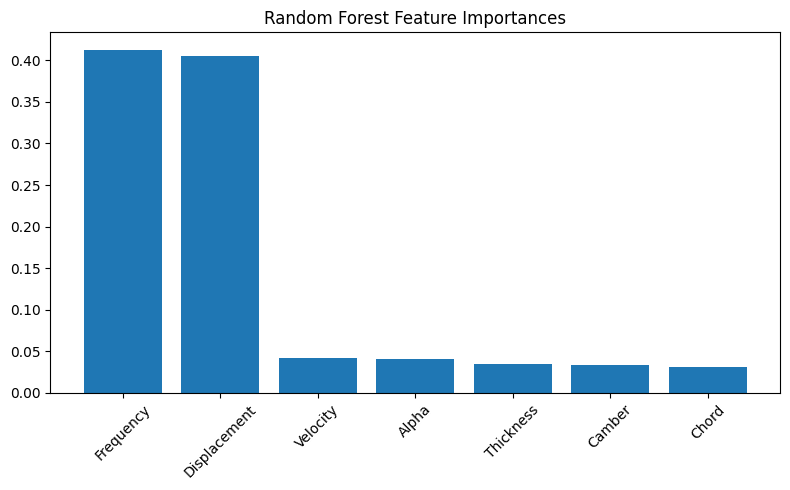

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the best model
importances = best_rf.feature_importances_
feature_names = ['Frequency', 'Alpha', 'Chord', 'Velocity', 'Displacement', 'Thickness', 'Camber']

# Sort descending
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.title('Random Forest Feature Importances')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=45)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()